In [74]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [75]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_per: float
    summary: str

In [79]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100
    return {'sr':sr}

def calculate_bpb(state: BatsmanState):

    bpb = (state['balls']/(state['sixes']+state['fours']))
    return {'bpb':bpb}

def calculate_boundary_per(state: BatsmanState):

    boundary_per = (((state['fours']*4) + (state['sixes']*6))/state['runs'])*100
    return {'boundary_per':boundary_per}

def summary(state: BatsmanState):

    summaryval = f"""
    Strike Rate - {state['sr']} \n
    Balls per Boundary - {state['bpb']} \n
    Boundary Percentage - {state['boundary_per']} \n
    """
    return {'summary' : summaryval}


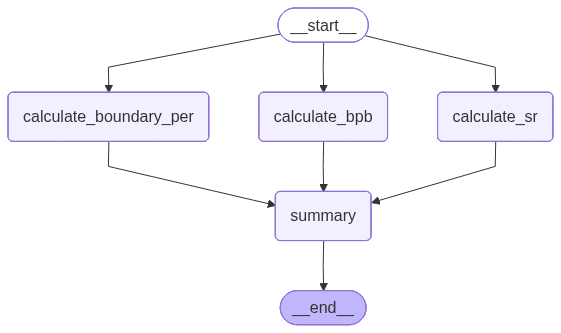

In [80]:
graph = StateGraph(BatsmanState)

# define nodes

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_per', calculate_boundary_per)
graph.add_node('summary', summary)

# define edges 

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_per')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_per', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()
workflow

In [81]:
initial_state = {
    'runs' : 100,
    'balls' : 50,
    'fours' : 6,
    'sixes' : 4
}
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_per': 48.0,
 'summary': '\n    Strike Rate - 200.0 \n\n    Balls per Boundary - 5.0 \n\n    Boundary Percentage - 48.0 \n\n    '}